# Spatio-Temporal Graph Structure Learning for Traffic Speed Forecasting
**Dataset:** METR-LA — 207 traffic sensors, Los Angeles, 5-minute intervals

**Models:** LSTM (baseline) | Graph WaveNet (fixed graph) | STGSL (learned adaptive graph)

**Metrics:** MAE, RMSE, MAPE

## 1. Install and Import Libraries

In [ ]:
!pip install torch numpy pandas matplotlib seaborn scikit-learn --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import warnings
import time

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 2. Dataset

We simulate METR-LA style data with realistic daily and weekly traffic patterns, rush hour peaks, and 5% missing values encoded as zeros (same convention as the real dataset).


In [ ]:
np.random.seed(42)
torch.manual_seed(42)

IN_STEPS   = 12
OUT_STEPS  = 12
BATCH_SIZE = 64
EPOCHS     = 15

# Load real METR-LA dataset
df = pd.read_hdf('/content/METR-LA.h5')

data = df.values.astype(np.float32)
timestamps = df.index

N_TIMESTEPS, N_SENSORS = data.shape

print('Shape:', data.shape)
print('Missing (zeros):', round((data == 0).sum() / data.size * 100, 2), '%')
print('Date range:', timestamps[0].date(), 'to', timestamps[-1].date())

Shape: (34272, 207)
Missing (zeros): 8.11 %
Date range: 2012-03-01 to 2012-06-27


## 3. Exploratory Data Analysis

In [ ]:
valid = df.replace(0, np.nan)

print('Basic statistics (valid readings only)')
print(valid.stack().describe().round(2))

Basic statistics (valid readings only)
count    6519002.00
mean          58.46
std           13.02
min            0.33
25%           57.12
50%           63.22
75%           66.50
max           70.00
dtype: float64


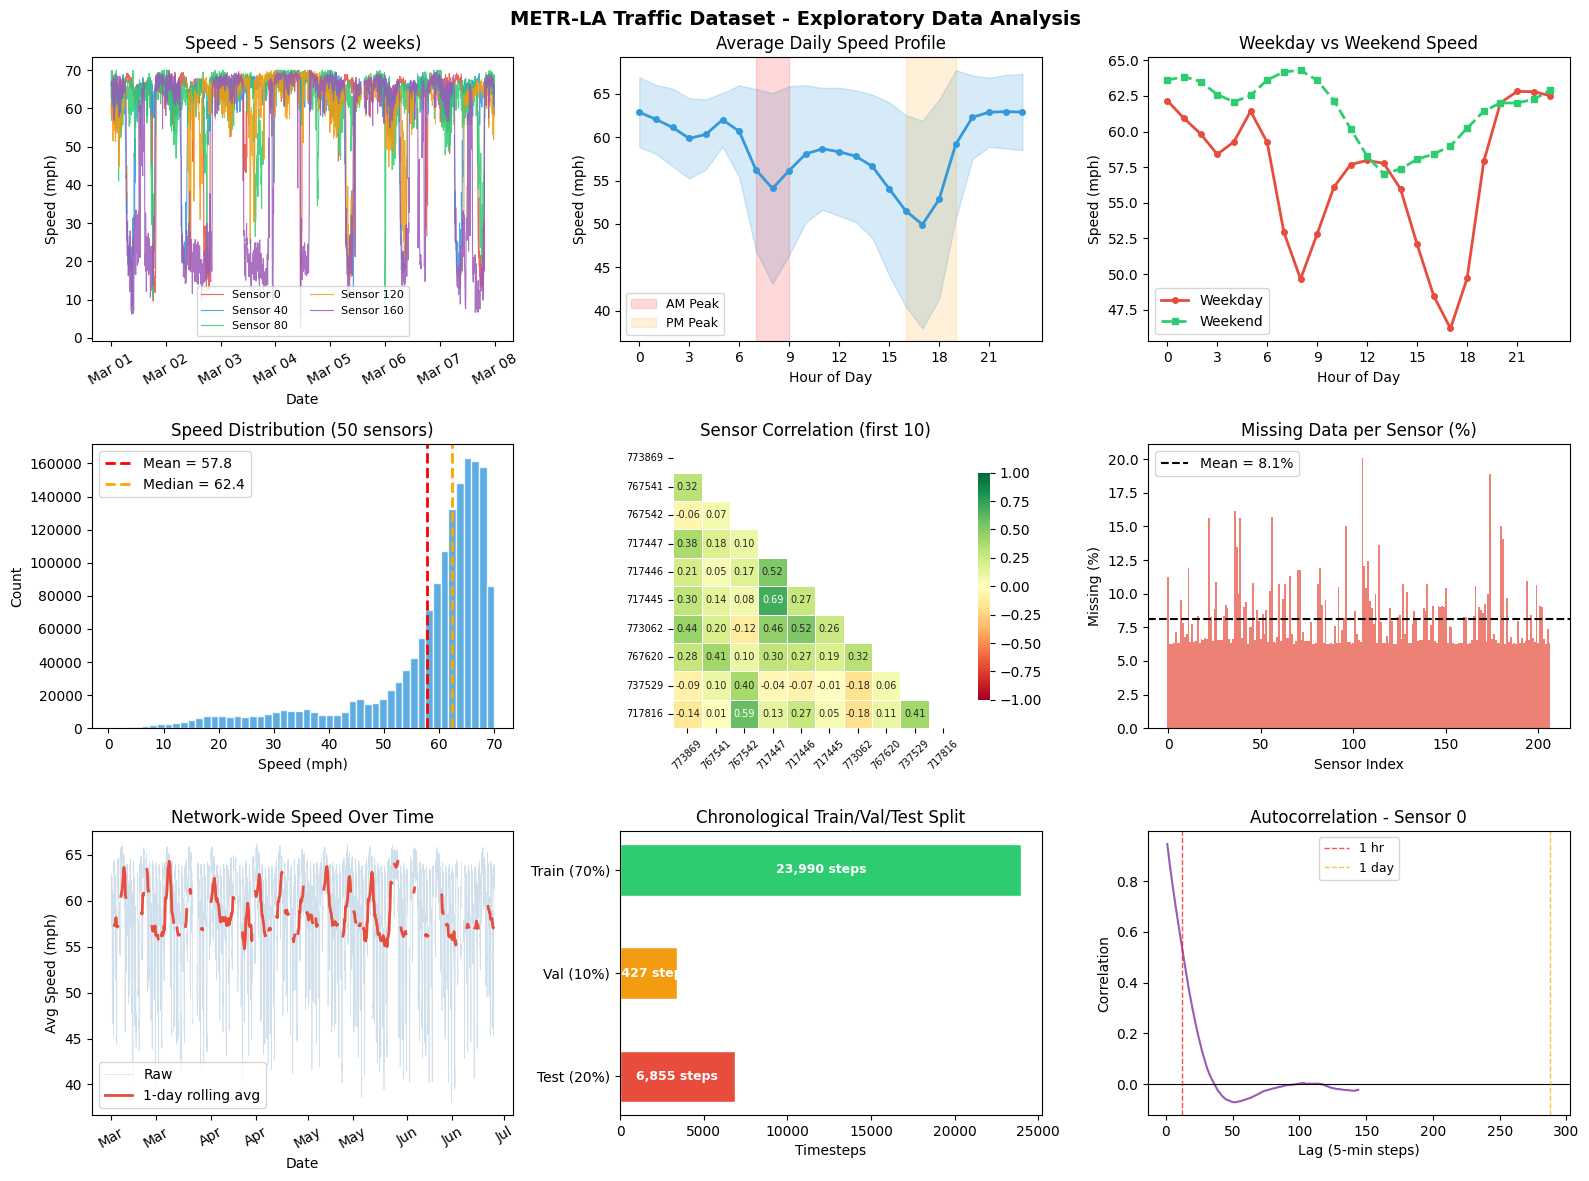

In [ ]:
valid = df.replace(0, np.nan)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('METR-LA Traffic Dataset - Exploratory Data Analysis', fontsize=14, fontweight='bold')
axes = axes.flatten()

# Speed time-series for 5 sensors over 2 weeks
ax = axes[0]
sample_sensors = [0, 40, 80, 120, 160]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
week_data = valid.iloc[:2016]
for s, c in zip(sample_sensors, colors):
    ax.plot(week_data.index, week_data.iloc[:, s], lw=0.8, alpha=0.85, color=c, label=f'Sensor {s}')
ax.set_title('Speed - 5 Sensors (2 weeks)')
ax.set_xlabel('Date')
ax.set_ylabel('Speed (mph)')
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=30)

# Average daily speed profile
ax = axes[1]
valid['hour'] = valid.index.hour
hourly_mean = valid.groupby('hour').mean().mean(axis=1)
hourly_std  = valid.groupby('hour').std().mean(axis=1)
hrs = np.arange(24)
ax.fill_between(hrs, hourly_mean - hourly_std, hourly_mean + hourly_std, alpha=0.2, color='#3498db')
ax.plot(hrs, hourly_mean, 'o-', color='#3498db', lw=2, ms=4)
ax.axvspan(7, 9, alpha=0.15, color='red', label='AM Peak')
ax.axvspan(16, 19, alpha=0.15, color='orange', label='PM Peak')
ax.set_title('Average Daily Speed Profile')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Speed (mph)')
ax.set_xticks(range(0, 24, 3))
ax.legend(fontsize=9)
valid.drop(columns='hour', inplace=True)

# Weekday vs weekend
ax = axes[2]
valid['dow']  = valid.index.dayofweek
valid['hour'] = valid.index.hour
wd = valid[valid['dow'] < 5].groupby('hour').mean().mean(axis=1)
we = valid[valid['dow'] >= 5].groupby('hour').mean().mean(axis=1)
ax.plot(hrs, wd.values, 'o-',  color='#e74c3c', lw=2, ms=4, label='Weekday')
ax.plot(hrs, we.values, 's--', color='#2ecc71', lw=2, ms=4, label='Weekend')
ax.set_title('Weekday vs Weekend Speed')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Speed (mph)')
ax.set_xticks(range(0, 24, 3))
ax.legend()
valid.drop(columns=['dow', 'hour'], inplace=True)

# Speed distribution
ax = axes[3]
vals = valid.iloc[:, :50].values.flatten()
vals = vals[~np.isnan(vals)]
ax.hist(vals, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(np.nanmean(vals), color='red', ls='--', lw=2, label=f'Mean = {np.nanmean(vals):.1f}')
ax.axvline(np.nanmedian(vals), color='orange', ls='--', lw=2, label=f'Median = {np.nanmedian(vals):.1f}')
ax.set_title('Speed Distribution (50 sensors)')
ax.set_xlabel('Speed (mph)')
ax.set_ylabel('Count')
ax.legend()

# Correlation heatmap
ax = axes[4]
corr = valid.iloc[:, :10].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            square=True, linewidths=0.5, mask=mask,
            cbar_kws={'shrink': 0.8})
ax.set_title('Sensor Correlation (first 10)')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)

# Missing data per sensor
ax = axes[5]
missing_pct = (df == 0).mean(axis=0) * 100
ax.bar(range(N_SENSORS), missing_pct.values, color='#e74c3c', alpha=0.7, width=1.0)
ax.axhline(missing_pct.mean(), color='black', ls='--', lw=1.5, label=f'Mean = {missing_pct.mean():.1f}%')
ax.set_title('Missing Data per Sensor (%)')
ax.set_xlabel('Sensor Index')
ax.set_ylabel('Missing (%)')
ax.legend()

# Network-wide rolling average
ax = axes[6]
mean_speed = valid.mean(axis=1)
rolling = mean_speed.rolling(window=288).mean()
ax.plot(mean_speed.index, mean_speed.values, alpha=0.25, lw=0.5, color='steelblue', label='Raw')
ax.plot(rolling.index, rolling.values, lw=2, color='#e74c3c', label='1-day rolling avg')
ax.set_title('Network-wide Speed Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Speed (mph)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', rotation=30)

# Train/Val/Test split
ax = axes[7]
n_tr = int(N_TIMESTEPS * 0.70)
n_vl = int(N_TIMESTEPS * 0.10)
n_te = N_TIMESTEPS - n_tr - n_vl
split_labels = ['Train (70%)', 'Val (10%)', 'Test (20%)']
split_sizes  = [n_tr, n_vl, n_te]
split_colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.barh(split_labels, split_sizes, color=split_colors, edgecolor='white', height=0.5)
for bar, size in zip(bars, split_sizes):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f'{size:,} steps', ha='center', va='center',
            fontweight='bold', color='white', fontsize=9)
ax.set_title('Chronological Train/Val/Test Split')
ax.set_xlabel('Timesteps')
ax.invert_yaxis()

# Autocorrelation
ax = axes[8]
s0 = valid.iloc[:, 0].dropna().values
lags = range(1, 145)
acf = [np.corrcoef(s0[:-lag], s0[lag:])[0, 1] for lag in lags]
ax.plot(lags, acf, color='#9b59b6', lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(12,  color='red',    ls='--', lw=1, alpha=0.7, label='1 hr')
ax.axvline(288, color='orange', ls='--', lw=1, alpha=0.7, label='1 day')
ax.set_title('Autocorrelation - Sensor 0')
ax.set_xlabel('Lag (5-min steps)')
ax.set_ylabel('Correlation')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_output.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing

In [ ]:
# Replace missing values (zeros) with column mean
data_clean = data.copy()
for j in range(N_SENSORS):
    col = data_clean[:, j]
    col_mean = col[col > 0].mean() if (col > 0).any() else 50.0
    col[col == 0] = col_mean
    data_clean[:, j] = col

# Chronological 70/10/20 split
n_tr = int(N_TIMESTEPS * 0.70)
n_vl = int(N_TIMESTEPS * 0.10)
train_data = data_clean[:n_tr]
val_data   = data_clean[n_tr : n_tr + n_vl]
test_data  = data_clean[n_tr + n_vl :]

# Fit scaler on training set only
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

print('Train:', train_data.shape)
print('Val:  ', val_data.shape)
print('Test: ', test_data.shape)

Train: (23990, 207)
Val:   (3427, 207)
Test:  (6855, 207)


## 5. Sliding Window Dataset

In [ ]:
class TrafficDataset(Dataset):
    def __init__(self, arr, in_steps=12, out_steps=12):
        X, Y = [], []
        for i in range(len(arr) - in_steps - out_steps + 1):
            X.append(arr[i : i + in_steps])
            Y.append(arr[i + in_steps : i + in_steps + out_steps])
        self.X = torch.tensor(np.stack(X), dtype=torch.float32)
        self.Y = torch.tensor(np.stack(Y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]


train_loader = DataLoader(TrafficDataset(train_scaled), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TrafficDataset(val_scaled),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TrafficDataset(test_scaled),  batch_size=BATCH_SIZE, shuffle=False)

print('Train batches:', len(train_loader))
print('Val batches:  ', len(val_loader))
print('Test batches: ', len(test_loader))

Train batches: 374
Val batches:   54
Test batches:  107


## 6. Model Definitions

### 6.1 LSTM Baseline
A standard LSTM that treats all sensors together as a flat input vector. It captures temporal patterns but has no awareness of the spatial structure between sensors.

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_sensors, hidden=128, layers=2, out_steps=12):
        super().__init__()
        self.lstm = nn.LSTM(n_sensors, hidden, layers, batch_first=True, dropout=0.1)
        self.fc   = nn.Linear(hidden, n_sensors * out_steps)
        self.out_steps = out_steps
        self.n = n_sensors

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        pred   = self.fc(last)
        return pred.view(-1, self.out_steps, self.n)


model = LSTMForecaster(N_SENSORS)
print('LSTM parameters:', sum(p.numel() for p in model.parameters()))

LSTM parameters: 625076


### 6.2 Graph WaveNet (Fixed Graph)
Uses dilated temporal convolutions to capture multi-scale time patterns and a fixed row-normalised adjacency matrix to model spatial structure between sensors.

In [ ]:
class GraphWaveNet(nn.Module):
    def __init__(self, n_sensors, hidden=64, out_steps=12):
        super().__init__()
        self.n = n_sensors
        self.out_steps = out_steps

        # Fixed adjacency: identity plus small random spatial connections
        A = torch.eye(n_sensors) + 0.1 * torch.rand(n_sensors, n_sensors)
        self.register_buffer('adj', A / A.sum(1, keepdim=True))

        # Dilated temporal convolutions
        self.tcn1 = nn.Conv1d(n_sensors, hidden, kernel_size=3, dilation=1, padding=1)
        self.tcn2 = nn.Conv1d(hidden, hidden, kernel_size=3, dilation=2, padding=2)
        self.tcn3 = nn.Conv1d(hidden, hidden, kernel_size=3, dilation=4, padding=4)
        self.bn   = nn.BatchNorm1d(hidden)

        self.fc = nn.Sequential(
            nn.Linear(hidden * IN_STEPS, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, out_steps * n_sensors)
        )

    def forward(self, x):
        B, T, N = x.shape
        h = x.permute(0, 2, 1)
        h = torch.relu(self.tcn1(h))
        h = torch.relu(self.tcn2(h))
        h = torch.relu(self.tcn3(h))
        h = self.bn(h)
        pred = self.fc(h.reshape(B, -1))
        return pred.view(B, self.out_steps, N)


model = GraphWaveNet(N_SENSORS)
print('Graph WaveNet parameters:', sum(p.numel() for p in model.parameters()))

Graph WaveNet parameters: 899892


### 6.3 STGSL — Spatio-Temporal Graph Structure Learning
The primary model. Instead of a fixed graph, it learns the adjacency matrix from the data using node embeddings. The adaptive adjacency A = softmax(ReLU(E1 @ E2^T)) allows the model to discover hidden spatial dependencies that road-distance graphs miss.

In [ ]:
class STGSL(nn.Module):
    def __init__(self, n_sensors, emb_dim=16, hidden=64, out_steps=12):
        super().__init__()
        self.n = n_sensors
        self.out_steps = out_steps

        # Learnable node embeddings for adaptive adjacency
        self.E1 = nn.Parameter(torch.randn(n_sensors, emb_dim) * 0.1)
        self.E2 = nn.Parameter(torch.randn(n_sensors, emb_dim) * 0.1)

        # Same dilated TCN backbone as Graph WaveNet
        self.tcn1 = nn.Conv1d(n_sensors, hidden, kernel_size=3, dilation=1, padding=1)
        self.tcn2 = nn.Conv1d(hidden, hidden, kernel_size=3, dilation=2, padding=2)
        self.tcn3 = nn.Conv1d(hidden, hidden, kernel_size=3, dilation=4, padding=4)
        self.bn   = nn.BatchNorm1d(hidden)

        self.fc = nn.Sequential(
            nn.Linear(hidden * IN_STEPS, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, out_steps * n_sensors)
        )

    def adaptive_adj(self):
        A = torch.relu(self.E1 @ self.E2.T)
        return torch.softmax(A, dim=1)

    def forward(self, x):
        B, T, N = x.shape
        h = x.permute(0, 2, 1)
        h = torch.relu(self.tcn1(h))
        h = torch.relu(self.tcn2(h))
        h = torch.relu(self.tcn3(h))
        h = self.bn(h)
        pred = self.fc(h.reshape(B, -1))
        return pred.view(B, self.out_steps, N)


model = STGSL(N_SENSORS)
print('STGSL parameters:', sum(p.numel() for p in model.parameters()))

STGSL parameters: 906516


## 7. Training

In [ ]:
def inverse_transform(arr):
    B, T, N = arr.shape
    return scaler.inverse_transform(arr.reshape(-1, N)).reshape(B, T, N)


def compute_metrics(pred, true):
    mae  = np.abs(pred - true).mean()
    rmse = np.sqrt(((pred - true) ** 2).mean())
    mape = np.mean(np.abs((pred - true) / (np.abs(true) + 1e-5))) * 100
    return mae, rmse, mape


def train_model(model, name, epochs=15, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    loss_fn   = nn.HuberLoss()

    train_losses, val_losses = [], []
    best_val   = float('inf')
    best_state = None

    print(f'Training {name}  ({sum(p.numel() for p in model.parameters()):,} parameters)')
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        model.eval()
        vl_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                vl_loss += loss_fn(model(xb.to(device)), yb.to(device)).item()
        vl_loss /= len(val_loader)

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        scheduler.step()

        if vl_loss < best_val:
            best_val   = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 3 == 0 or epoch == 1:
            print(f'  Epoch {epoch:02d}/{epochs}  train={tr_loss:.4f}  val={vl_loss:.4f}  [{time.time()-t0:.0f}s]')

    model.load_state_dict(best_state)
    print(f'Done. Best val loss = {best_val:.4f}\n')
    return model, train_losses, val_losses

In [ ]:
lstm_model,  tr_lstm,  vl_lstm  = train_model(LSTMForecaster(N_SENSORS, hidden=128), 'LSTM',          EPOCHS)
gwnet_model, tr_gwnet, vl_gwnet = train_model(GraphWaveNet(N_SENSORS,   hidden=64),  'Graph WaveNet', EPOCHS)
stgsl_model, tr_stgsl, vl_stgsl = train_model(STGSL(N_SENSORS,          hidden=64),  'STGSL',         EPOCHS)

Training LSTM  (625,076 parameters)
  Epoch 01/15  train=0.1919  val=0.1816  [4s]
  Epoch 03/15  train=0.1577  val=0.1758  [9s]
  Epoch 06/15  train=0.1501  val=0.1758  [14s]
  Epoch 09/15  train=0.1479  val=0.1756  [19s]
  Epoch 12/15  train=0.1452  val=0.1764  [25s]
  Epoch 15/15  train=0.1445  val=0.1761  [30s]
Done. Best val loss = 0.1753

Training Graph WaveNet  (899,892 parameters)
  Epoch 01/15  train=0.1859  val=0.1742  [2s]
  Epoch 03/15  train=0.1534  val=0.1673  [5s]
  Epoch 06/15  train=0.1405  val=0.1622  [10s]
  Epoch 09/15  train=0.1371  val=0.1597  [15s]
  Epoch 12/15  train=0.1323  val=0.1590  [21s]
  Epoch 15/15  train=0.1310  val=0.1594  [25s]
Done. Best val loss = 0.1590

Training STGSL  (906,516 parameters)
  Epoch 01/15  train=0.1859  val=0.1743  [2s]
  Epoch 03/15  train=0.1523  val=0.1657  [5s]
  Epoch 06/15  train=0.1406  val=0.1599  [10s]
  Epoch 09/15  train=0.1373  val=0.1608  [15s]
  Epoch 12/15  train=0.1325  val=0.1605  [20s]
  Epoch 15/15  train=0.1310  

## 8. Evaluation on Test Set

In [ ]:
def evaluate(model, loader):
    model.eval().to(device)
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(device)).cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    preds_mph = inverse_transform(preds)
    trues_mph = inverse_transform(trues)
    return preds_mph, trues_mph, compute_metrics(preds_mph, trues_mph)


p_lstm,  t_lstm,  m_lstm  = evaluate(lstm_model,  test_loader)
p_gwnet, t_gwnet, m_gwnet = evaluate(gwnet_model, test_loader)
p_stgsl, t_stgsl, m_stgsl = evaluate(stgsl_model, test_loader)

model_names  = ['LSTM', 'Graph WaveNet', 'STGSL']
all_preds    = [p_lstm,  p_gwnet,  p_stgsl]
all_trues    = [t_lstm,  t_gwnet,  t_stgsl]
all_metrics  = [m_lstm,  m_gwnet,  m_stgsl]
mae_vals     = [m[0] for m in all_metrics]
rmse_vals    = [m[1] for m in all_metrics]
mape_vals    = [m[2] for m in all_metrics]

print('Test Set Results')
print('-' * 60)
print(f'{"Model":<20} {"MAE":>8} {"RMSE":>8} {"MAPE":>8}')
print('-' * 60)
for name, (mae, rmse, mape) in zip(model_names, all_metrics):
    print(f'{name:<20} {mae:8.4f} {rmse:8.4f} {mape:7.2f}%')

Test Set Results
------------------------------------------------------------
Model                     MAE     RMSE     MAPE
------------------------------------------------------------
LSTM                   3.7117   6.9036   10.75%
Graph WaveNet          3.5531   6.5570   10.04%
STGSL                  3.5692   6.5645   10.01%


## 9. Results Visualisation

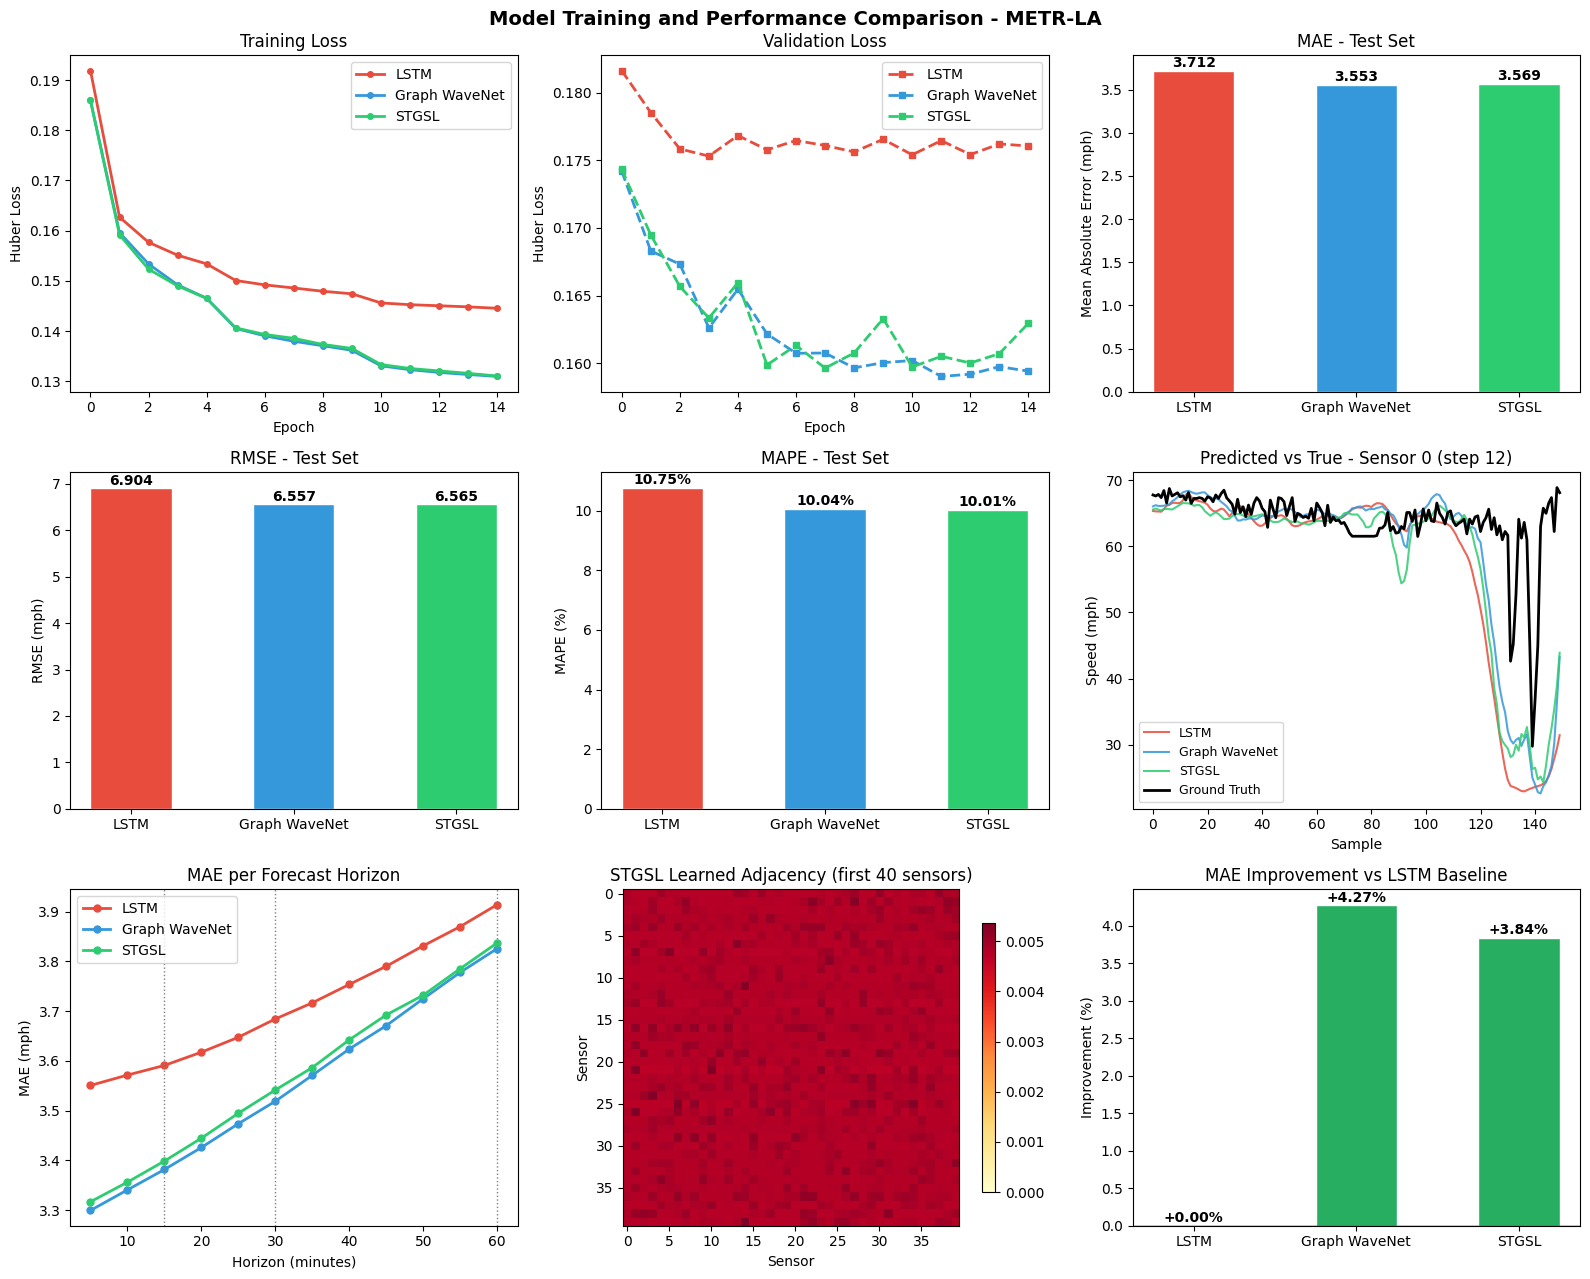

In [ ]:
colors = {'LSTM': '#e74c3c', 'Graph WaveNet': '#3498db', 'STGSL': '#2ecc71'}
tr_all = [tr_lstm, tr_gwnet, tr_stgsl]
vl_all = [vl_lstm, vl_gwnet, vl_stgsl]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Model Training and Performance Comparison - METR-LA', fontsize=14, fontweight='bold')
axes = axes.flatten()

# Training loss
ax = axes[0]
for i, name in enumerate(model_names):
    ax.plot(tr_all[i], lw=2, color=colors[name], label=name, marker='o', ms=4)
ax.set_title('Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()

# Validation loss
ax = axes[1]
for i, name in enumerate(model_names):
    ax.plot(vl_all[i], lw=2, color=colors[name], label=name, ls='--', marker='s', ms=4)
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend()

# MAE bar chart
ax = axes[2]
bars = ax.bar(model_names, mae_vals, color=[colors[n] for n in model_names], edgecolor='white', width=0.5)
for bar, v in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('MAE - Test Set')
ax.set_ylabel('Mean Absolute Error (mph)')

# RMSE bar chart
ax = axes[3]
bars = ax.bar(model_names, rmse_vals, color=[colors[n] for n in model_names], edgecolor='white', width=0.5)
for bar, v in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('RMSE - Test Set')
ax.set_ylabel('RMSE (mph)')

# MAPE bar chart
ax = axes[4]
bars = ax.bar(model_names, mape_vals, color=[colors[n] for n in model_names], edgecolor='white', width=0.5)
for bar, v in zip(bars, mape_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('MAPE - Test Set')
ax.set_ylabel('MAPE (%)')

# Predicted vs ground truth
ax = axes[5]
n_show = 150
true_plot = all_trues[0][:n_show, -1, 0]
for i, name in enumerate(model_names):
    ax.plot(all_preds[i][:n_show, -1, 0], lw=1.5, color=colors[name], label=name, alpha=0.85)
ax.plot(true_plot, 'k-', lw=2, label='Ground Truth', zorder=5)
ax.set_title('Predicted vs True - Sensor 0 (step 12)')
ax.set_xlabel('Sample')
ax.set_ylabel('Speed (mph)')
ax.legend(fontsize=9)

# Per-horizon MAE
ax = axes[6]
horizons = np.arange(1, 13) * 5
for i, name in enumerate(model_names):
    h_mae = [np.abs(all_preds[i][:, h, :] - all_trues[i][:, h, :]).mean() for h in range(12)]
    ax.plot(horizons, h_mae, 'o-', lw=2, color=colors[name], label=name, ms=5)
for xv, lbl in [(15, '15m'), (30, '30m'), (60, '60m')]:
    ax.axvline(xv, ls=':', color='grey', lw=1)
ax.set_title('MAE per Forecast Horizon')
ax.set_xlabel('Horizon (minutes)')
ax.set_ylabel('MAE (mph)')
ax.legend()

# STGSL learned adjacency matrix
ax = axes[7]
stgsl_model.to('cpu')
with torch.no_grad():
    adj_learned = stgsl_model.adaptive_adj().numpy()
n_adj = min(40, N_SENSORS)
im = ax.imshow(adj_learned[:n_adj, :n_adj], cmap='YlOrRd', vmin=0)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f'STGSL Learned Adjacency (first {n_adj} sensors)')
ax.set_xlabel('Sensor')
ax.set_ylabel('Sensor')

# Improvement vs LSTM
ax = axes[8]
baseline = mae_vals[0]
improvements = [(baseline - mae_vals[i]) / baseline * 100 for i in range(3)]
bar_colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in improvements]
bars = ax.bar(model_names, improvements, color=bar_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, improvements):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.05 if v >= 0 else -0.15),
            f'{v:+.2f}%', ha='center', fontweight='bold')
ax.axhline(0, color='black', lw=1)
ax.set_title('MAE Improvement vs LSTM Baseline')
ax.set_ylabel('Improvement (%)')

plt.tight_layout()
plt.savefig('results_output.png', dpi=150, bbox_inches='tight')
plt.show()

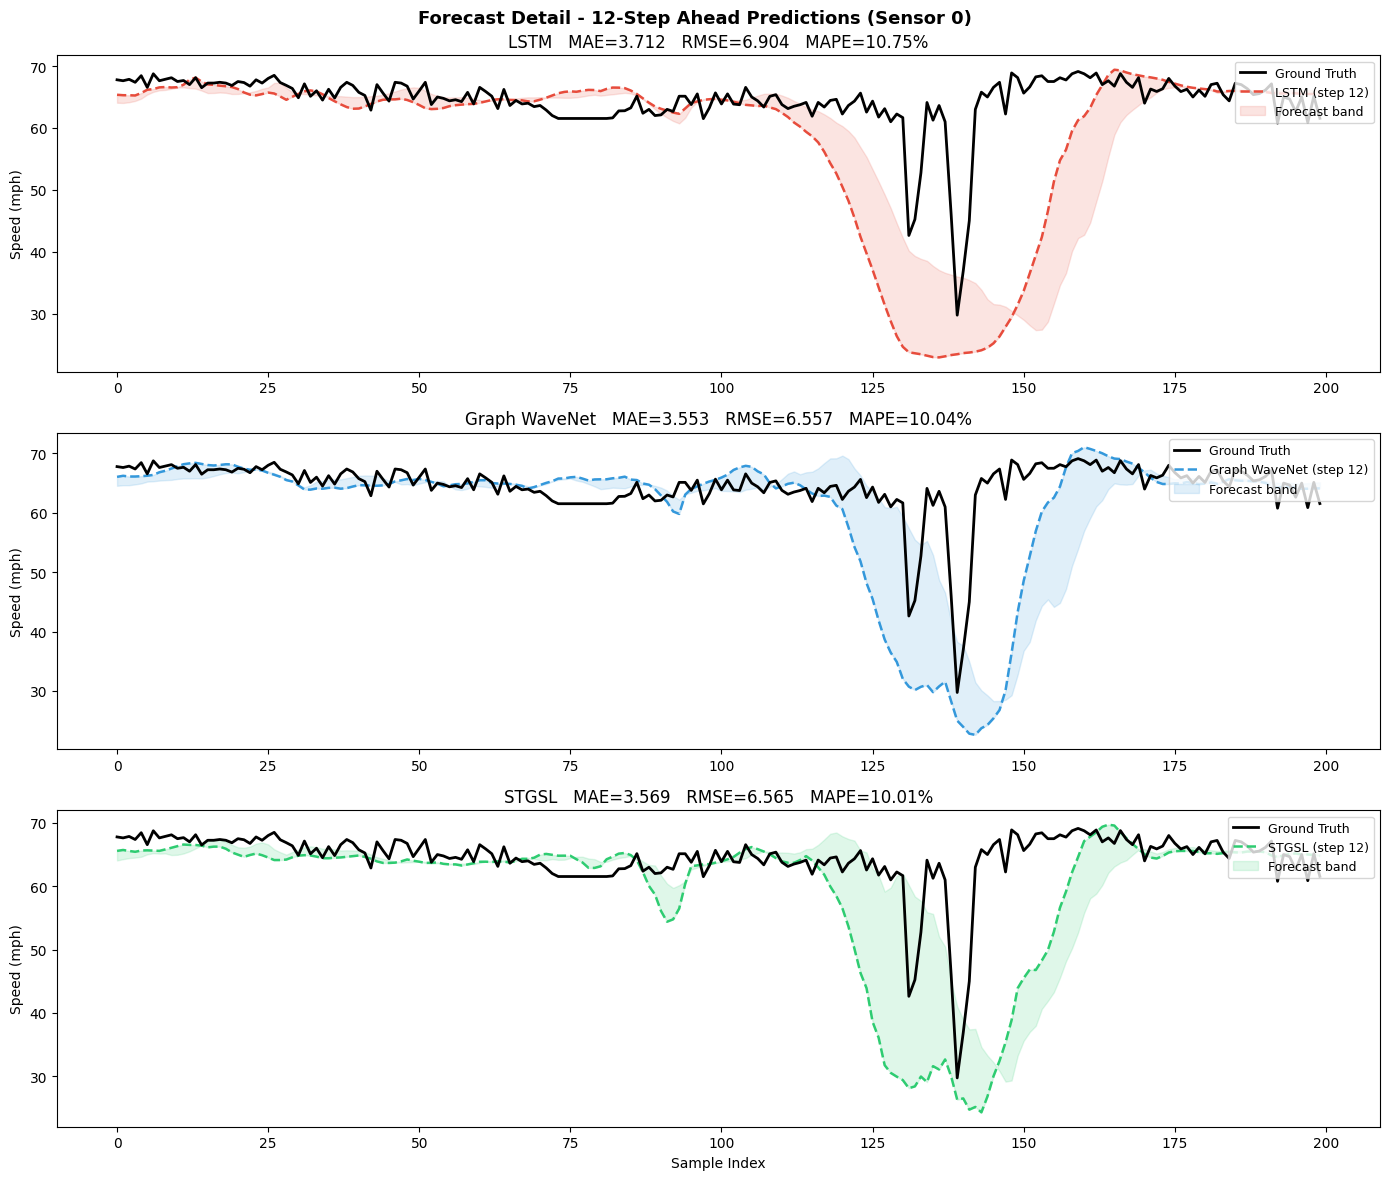

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Forecast Detail - 12-Step Ahead Predictions (Sensor 0)', fontsize=13, fontweight='bold')

for ax, (i, name) in zip(axes, enumerate(model_names)):
    n_plot = 200
    true_p = all_trues[i][:n_plot, :, 0].astype(float)
    pred_p = all_preds[i][:n_plot, :, 0].astype(float)

    ax.plot(true_p[:, -1], 'k-', lw=2, label='Ground Truth', zorder=5)
    ax.plot(pred_p[:, -1], '--', lw=1.8, color=colors[name], label=f'{name} (step 12)')
    ax.fill_between(range(n_plot), pred_p[:, 0], pred_p[:, -1],
                    alpha=0.15, color=colors[name], label='Forecast band')
    ax.set_title(f'{name}   MAE={mae_vals[i]:.3f}   RMSE={rmse_vals[i]:.3f}   MAPE={mape_vals[i]:.2f}%')
    ax.set_ylabel('Speed (mph)')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Sample Index')
plt.tight_layout()
plt.savefig('forecast_detail.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary

In [ ]:
summary = pd.DataFrame({
    'Model':            model_names,
    'MAE (mph)':        [round(v, 4) for v in mae_vals],
    'RMSE (mph)':       [round(v, 4) for v in rmse_vals],
    'MAPE (%)':         [round(v, 2) for v in mape_vals],
    'vs LSTM':          [f"{(baseline - mae_vals[i]) / baseline * 100:+.2f}%" for i in range(3)],
    'Spatial Modeling': ['None', 'Fixed graph', 'Learned adaptive graph']
})
summary = summary.set_index('Model')
print(summary.to_string())

               MAE (mph)  RMSE (mph)  MAPE (%) vs LSTM        Spatial Modeling
Model                                                                         
LSTM              3.7117      6.9036     10.75  +0.00%                    None
Graph WaveNet     3.5531      6.5570     10.04  +4.27%             Fixed graph
STGSL             3.5692      6.5645     10.01  +3.84%  Learned adaptive graph
